In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict


# Cấu hình giao diện đồ thị
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# AOD data EDA

In [2]:
dir = r"/home/slow_data/Air_Quality/AOD/L3_AOD/"

In [3]:
base_dir = Path(dir)

## Data Stat

In [4]:
data_structure = []

for yyyymm_dir in sorted(base_dir.glob('[0-9][0-9][0-9][0-9][0-9][0-9]')):
    year_month = yyyymm_dir.name
    
    for dd_dir in sorted(yyyymm_dir.glob('[0-9][0-9]')):
        day = dd_dir.name
        
        # Count .tif files
        tif_files = list(dd_dir.glob('*.tif'))
        n_files = len(tif_files)
        
        data_structure.append({
            'year_month': year_month,
            'day': day,
            'datetime': f"{year_month}{day}",
            'n_files': n_files,
            'expected': 24,
            'status': 'complete' if n_files == 24 else 'incomplete',
            'missing': 24 - n_files if n_files < 24 else 0,
            'path': str(dd_dir)
        })

df = pd.DataFrame(data_structure)
print(f"Total hours scanned: {len(df)}")
df.head(10)

Total hours scanned: 734


,year_month,day,datetime,n_files,expected,status,missing,path
0,202401,01,20240101,24,24,complete,0,/home/slow_data/Air_Quality/AOD/L3_AOD/202401/01
1,202401,02,20240102,24,24,complete,0,/home/slow_data/Air_Quality/AOD/L3_AOD/202401/02
2,202401,03,20240103,24,24,complete,0,/home/slow_data/Air_Quality/AOD/L3_AOD/202401/03
3,202401,04,20240104,24,24,complete,0,/home/slow_data/Air_Quality/AOD/L3_AOD/202401/04
4,202401,05,20240105,24,24,complete,0,/home/slow_data/Air_Quality/AOD/L3_AOD/202401/05
5,202401,06,20240106,24,24,complete,0,/home/slow_data/Air_Quality/AOD/L3_AOD/202401/06
6,202401,07,20240107,24,24,complete,0,/home/slow_data/Air_Quality/AOD/L3_AOD/202401/07
7,202401,08,20240108,24,24,complete,0,/home/slow_data/Air_Quality/AOD/L3_AOD/202401/08
8,202401,09,20240109,24,24,complete,0,/home/slow_data/Air_Quality/AOD/L3_AOD/202401/09
9,202401,10,20240110,24,24,complete,0,/home/slow_data/Air_Quality/AOD/L3_AOD/202401/10


In [5]:
print("=== OVERALL STATISTICS ===")
print(f"Total days in dataset: {len(df)}")
print(f"Total files found: {df['n_files'].sum()}")
print(f"Expected total files: {len(df) * 24}")
print(f"Missing files: {df['missing'].sum()}")
print(f"\nComplete days (24 files): {(df['status'] == 'complete').sum()}")
print(f"Incomplete days: {(df['status'] == 'incomplete').sum()}")
print(f"Completeness rate: {(df['status'] == 'complete').sum() / len(df) * 100:.2f}%")

=== OVERALL STATISTICS ===
Total days in dataset: 734
Total files found: 17488
Expected total files: 17616
Missing files: 128

Complete days (24 files): 701
Incomplete days: 33
Completeness rate: 95.50%


In [6]:
print("\n=== FILES PER DAT DISTRIBUTION ===")
print(df['n_files'].value_counts().sort_index())
print("\nPercentage:")
percent=df['n_files'].value_counts(normalize=True).sort_index() * 100
print(percent)


=== FILES PER DAT DISTRIBUTION ===
n_files
1       1
2       1
3       1
13      1
14      1
17      1
21      1
22      5
23     21
24    701
Name: count, dtype: int64

Percentage:
n_files
1      0.136240
2      0.136240
3      0.136240
13     0.136240
14     0.136240
17     0.136240
21     0.136240
22     0.681199
23     2.861035
24    95.504087
Name: proportion, dtype: float64


In [10]:
monthly_stats = df.groupby('year_month').agg({
    'n_files': ['count', 'sum', 'mean'],
    'missing': 'sum',
    'status': lambda x: (x == 'complete').sum()
}).round(2)

monthly_stats.columns = ['n_days', 'total_files', 'avg_files_per_day', 'missing_files', 'complete_days']
monthly_stats['completeness_pct'] = (monthly_stats['complete_days'] / monthly_stats['n_days'] * 100).round(2)
print("\n=== MONTHLY STATISTICS ===")
print(monthly_stats)


=== MONTHLY STATISTICS ===
            n_days  total_files  avg_files_per_day  missing_files  \
year_month                                                          
202401          31          744              24.00              0   
202402          29          693              23.90              3   
202403          31          743              23.97              1   
202404          30          720              24.00              0   
202405          31          742              23.94              2   
202406          30          720              24.00              0   
202407          31          744              24.00              0   
202408          31          744              24.00              0   
202409          30          719              23.97              1   
202410          31          744              24.00              0   
202411          30          717              23.90              3   
202412          31          736              23.74              8   
202501

In [11]:
# selected_month = df['year_month'].iloc[0]  # Change as needed
# print(f"\n=== DAILY STATISTICS FOR {selected_month} ===")

# daily_stats = df[df['year_month'] == selected_month].groupby('day').agg({
#     'n_files': ['count', 'sum', 'mean'],
#     'missing': 'sum',
#     'status': lambda x: (x == 'complete').sum()
# }).round(2)

# daily_stats.columns = ['n_hours', 'total_files', 'avg_files', 'missing', 'complete_hours']
# print(daily_stats)

In [7]:
incomplete_df = df[df['status'] == 'incomplete'].copy()
print(f"\n=== INCOMPLETE DAYS ({len(incomplete_df)} total) ===")
print(incomplete_df[['datetime', 'n_files', 'missing', 'path']].head(20))


=== INCOMPLETE DAYS (33 total) ===
     datetime  n_files  missing  \
44   20240214       23        1   
49   20240219       23        1   
51   20240221       23        1   
75   20240316       23        1   
124  20240504       22        2   
264  20240921       23        1   
323  20241119       23        1   
325  20241121       23        1   
329  20241125       23        1   
338  20241204       23        1   
340  20241206       23        1   
341  20241207       23        1   
350  20241216       23        1   
356  20241222       22        2   
362  20241228       22        2   
370  20250105       23        1   
372  20250107       23        1   
377  20250112       23        1   
379  20250114       23        1   
383  20250118       23        1   

                                                 path  
44   /home/slow_data/Air_Quality/AOD/L3_AOD/202402/14  
49   /home/slow_data/Air_Quality/AOD/L3_AOD/202402/19  
51   /home/slow_data/Air_Quality/AOD/L3_AOD/202402/21  
75  

In [8]:
zero_files = df[df['n_files'] == 0]
print(f"\n=== DAYS WITH ZERO FILES ({len(zero_files)} total) ===")
if len(zero_files) > 0:
    print(zero_files[['datetime', 'path']].head(20))
else:
    print("No days with zero files found!")


=== DAYS WITH ZERO FILES (0 total) ===
No days with zero files found!


/tmp/ipykernel_430747/663043232.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_complete = df.groupby('year_month').apply(lambda x: (x['status'] == 'complete').sum() / len(x) * 100)


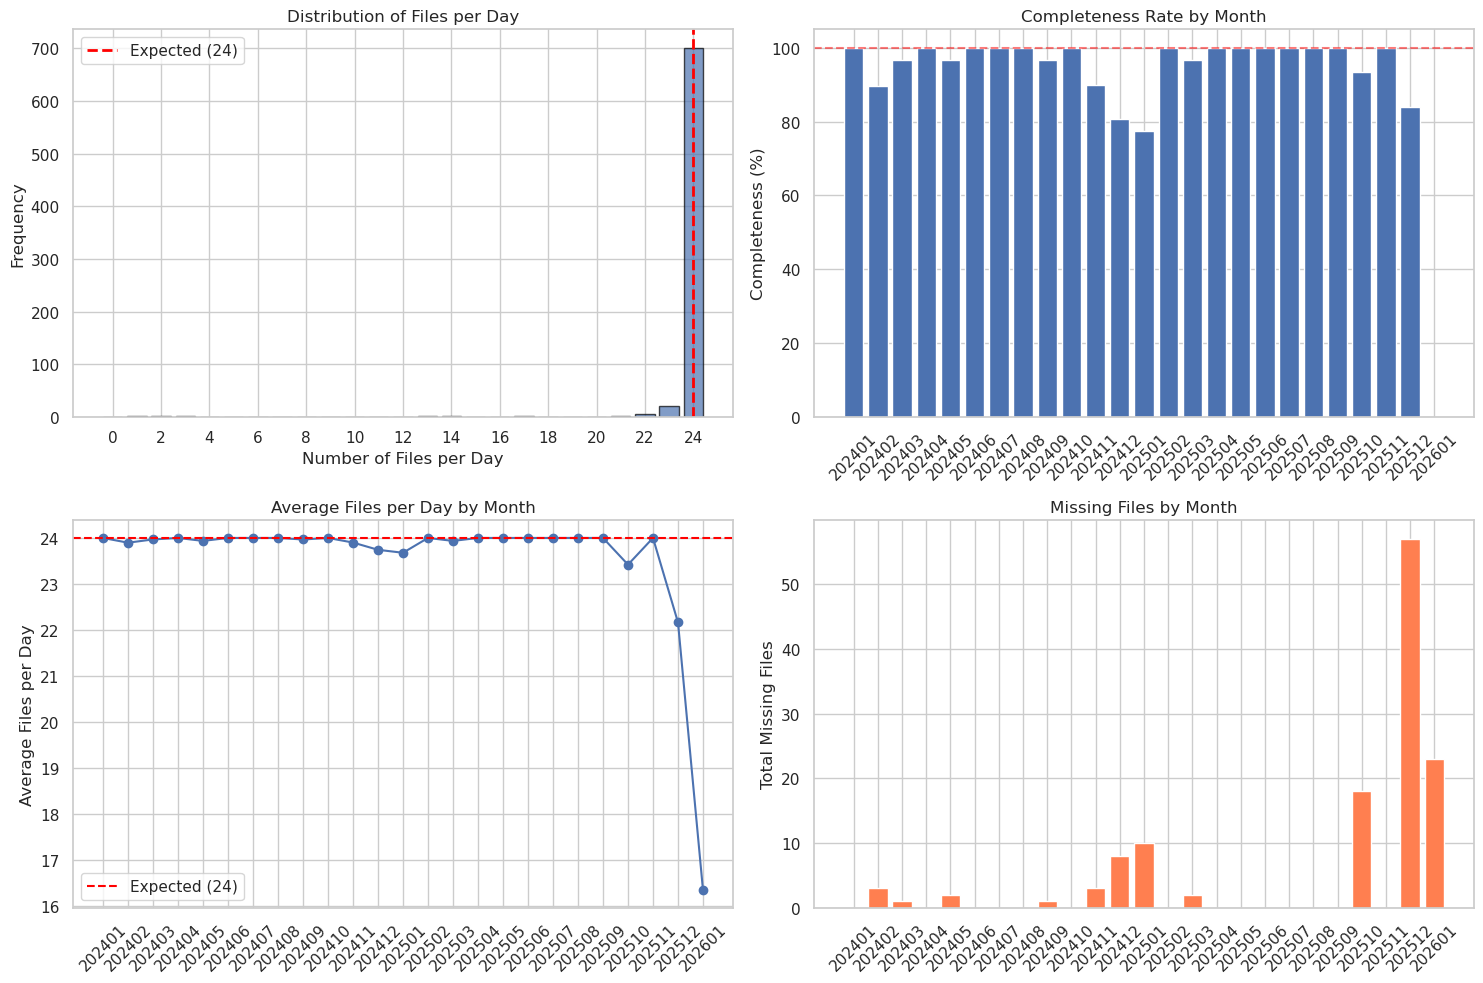

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram of files per Day
axes[0, 0].hist(df['n_files'], bins=range(0, 26), edgecolor='black', alpha=0.7, align='left', rwidth=0.8)
axes[0, 0].set_xlabel('Number of Files per Day')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Files per Day')
axes[0, 0].set_xticks(range(0, 25, 2)) 
axes[0, 0].axvline(24, color='red', linestyle='--', linewidth=2, label='Expected (24)')
axes[0, 0].legend()

# Completeness by month
monthly_complete = df.groupby('year_month').apply(lambda x: (x['status'] == 'complete').sum() / len(x) * 100)
axes[0, 1].bar(range(len(monthly_complete)), monthly_complete.values)
axes[0, 1].set_xticks(range(len(monthly_complete)))
axes[0, 1].set_xticklabels(monthly_complete.index, rotation=45)
axes[0, 1].set_ylabel('Completeness (%)')
axes[0, 1].set_title('Completeness Rate by Month')
axes[0, 1].axhline(100, color='red', linestyle='--', alpha=0.5)

# Average files per Day by month
monthly_avg = df.groupby('year_month')['n_files'].mean()
axes[1, 0].plot(monthly_avg.values, marker='o')
axes[1, 0].set_xticks(range(len(monthly_avg)))
axes[1, 0].set_xticklabels(monthly_avg.index, rotation=45)
axes[1, 0].set_ylabel('Average Files per Day')
axes[1, 0].set_title('Average Files per Day by Month')
axes[1, 0].axhline(24, color='red', linestyle='--', label='Expected (24)')
axes[1, 0].legend()

# Missing files by month
monthly_missing = df.groupby('year_month')['missing'].sum()
axes[1, 1].bar(range(len(monthly_missing)), monthly_missing.values, color='coral')
axes[1, 1].set_xticks(range(len(monthly_missing)))
axes[1, 1].set_xticklabels(monthly_missing.index, rotation=45)
axes[1, 1].set_ylabel('Total Missing Files')
axes[1, 1].set_title('Missing Files by Month')

plt.tight_layout()
plt.show()

In [22]:
df['datetime_obj'] = pd.to_datetime(df['datetime'], format='%Y%m%d')
df_sorted = df.sort_values('datetime_obj')

time_diffs = df_sorted['datetime_obj'].diff()
gaps = time_diffs[time_diffs > timedelta(days=2)]

print(f"\n=== TIME SERIES GAPS (> 2 day) ===")
print(f"Number of gaps: {len(gaps)}")
if len(gaps) > 0:
    for idx, gap in gaps.items():
        prev_time = df_sorted.loc[idx - 1, 'datetime_obj']
        curr_time = df_sorted.loc[idx, 'datetime_obj']
        print(f"Gap from {prev_time} to {curr_time}: {gap}")


=== TIME SERIES GAPS (> 2 day) ===
Number of gaps: 0


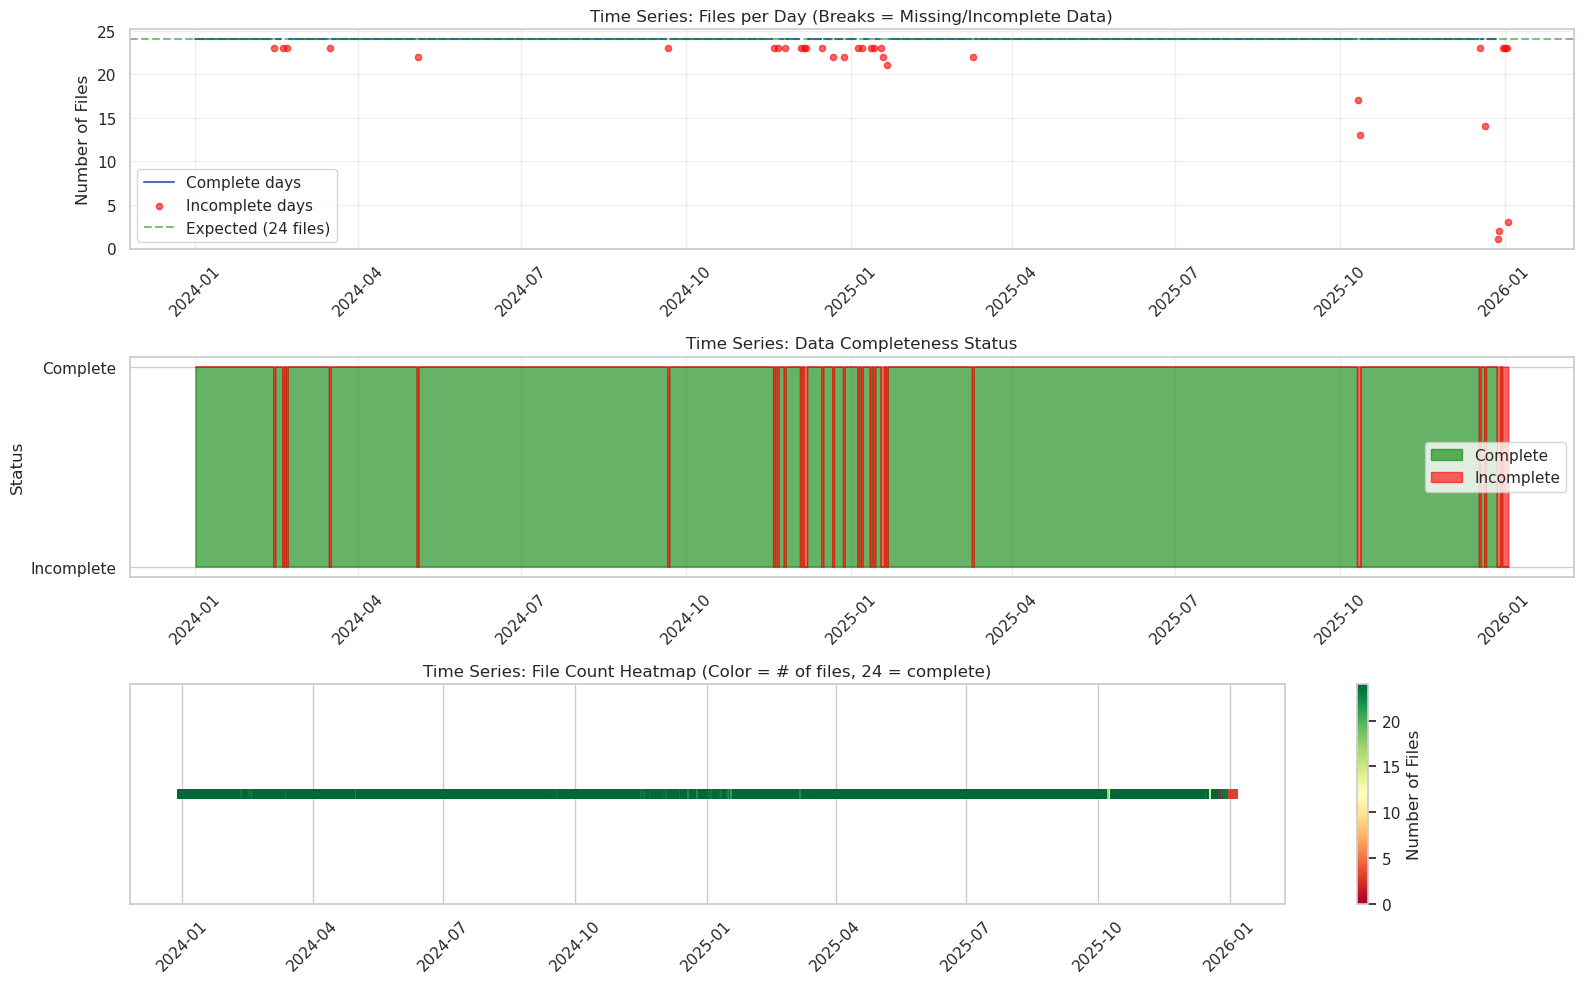

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# Prepare data with datetime
df_sorted = df.sort_values('datetime_obj').reset_index(drop=True)

# Method 1: Line plot with breaks (NaN for incomplete)
df_plot1 = df_sorted.copy()
df_plot1.loc[df_plot1['status'] == 'incomplete', 'n_files_plot'] = None
df_plot1.loc[df_plot1['status'] == 'complete', 'n_files_plot'] = df_plot1['n_files']

axes[0].plot(df_plot1['datetime_obj'], df_plot1['n_files_plot'], 
              markersize=3, linewidth=1.5, label='Complete days')
axes[0].scatter(df_sorted[df_sorted['status'] == 'incomplete']['datetime_obj'],
                df_sorted[df_sorted['status'] == 'incomplete']['n_files'],
                color='red', s=20, alpha=0.6, label='Incomplete days', zorder=5)
axes[0].axhline(24, color='green', linestyle='--', alpha=0.5, label='Expected (24 files)')
axes[0].set_ylabel('Number of Files')
axes[0].set_title('Time Series: Files per Day (Breaks = Missing/Incomplete Data)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Method 2: Completeness indicator (binary: complete or not)
completeness = (df_sorted['status'] == 'complete').astype(int)
axes[1].fill_between(df_sorted['datetime_obj'], 0, completeness, 
                      step='mid', alpha=0.6, color='green', label='Complete')
axes[1].fill_between(df_sorted['datetime_obj'], completeness, 1,
                      step='mid', alpha=0.6, color='red', label='Incomplete')
axes[1].set_ylabel('Status')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Incomplete', 'Complete'])
axes[1].set_title('Time Series: Data Completeness Status')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

# Method 3: Heatmap-style timeline showing file count
# Create breaks by setting incomplete to NaN
df_plot3 = df_sorted.copy()
df_plot3.loc[df_plot3['n_files'] < 24, 'n_files_heat'] = None
df_plot3.loc[df_plot3['n_files'] == 24, 'n_files_heat'] = df_plot3['n_files']

# Plot with color intensity
scatter = axes[2].scatter(df_sorted['datetime_obj'], 
                          [1]*len(df_sorted),
                          c=df_sorted['n_files'], 
                          cmap='RdYlGn', 
                          vmin=0, vmax=24,
                          s=50, 
                          marker='s',
                          edgecolors='none',
                          linewidths=0.5)
axes[2].set_ylabel('')
axes[2].set_yticks([])
axes[2].set_title('Time Series: File Count Heatmap (Color = # of files, 24 = complete)')
plt.colorbar(scatter, ax=axes[2], label='Number of Files')
axes[2].set_ylim(0.5, 1.5)

# Format x-axis for all plots
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

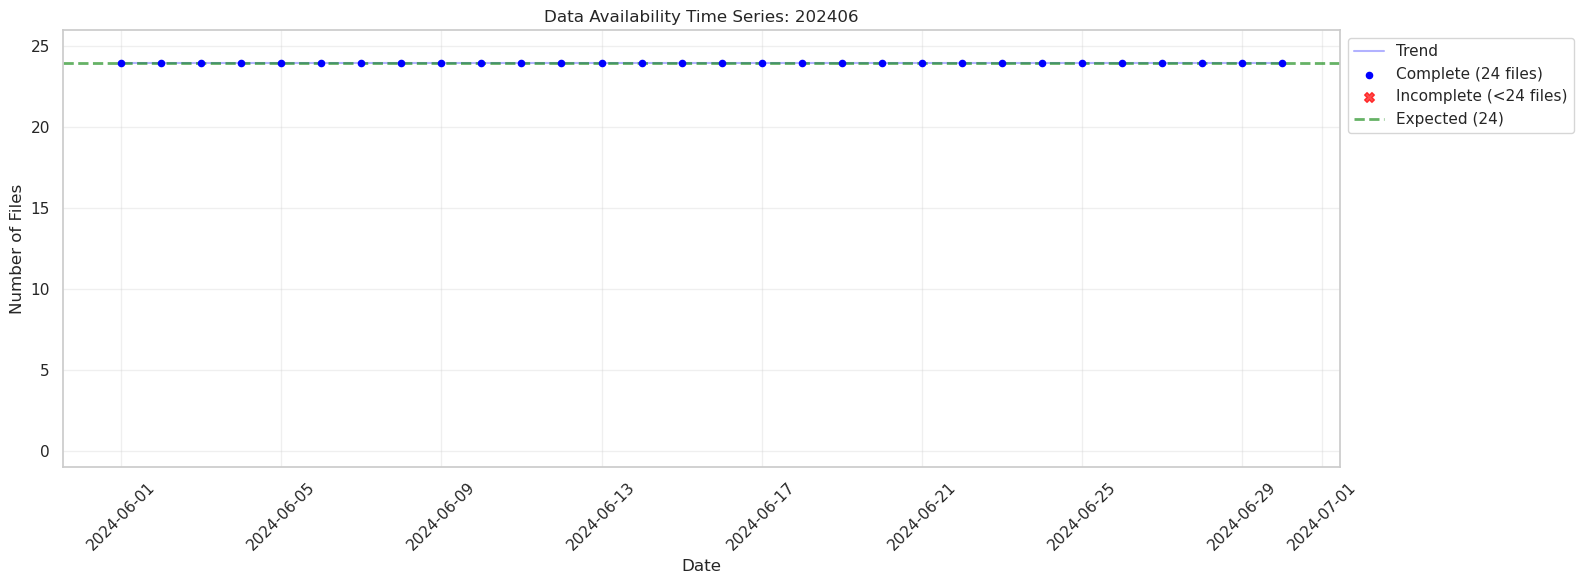

In [34]:
selected_month = '202406' 
df_month = df_sorted[df_sorted['year_month'] == selected_month].copy()

fig, ax = plt.subplots(figsize=(16, 6))

# 1. Plot the continuous line using the FULL monthly dataframe 
# This ensures that gaps in the data actually show up as gaps in the line
ax.plot(df_month['datetime_obj'], df_month['n_files'], 
        linewidth=1.5, color='blue', alpha=0.3, label='Trend', zorder=2)

# 2. Highlight complete days
df_complete = df_month[df_month['status'] == 'complete']
ax.scatter(df_complete['datetime_obj'], df_complete['n_files'], 
           s=20, color='blue', label='Complete (24 files)', zorder=3)

# 3. Plot incomplete days as disconnected points
df_incomplete = df_month[(df_month['status'] == 'incomplete') & (df_month['n_files'] > 0)]
ax.scatter(df_incomplete['datetime_obj'], df_incomplete['n_files'],
           color='red', s=50, alpha=0.7, marker='X', 
           label='Incomplete (<24 files)', zorder=5)

# 4. Mark days with 0 files
df_zero = df_month[df_month['n_files'] == 0]
if not df_zero.empty:
    ax.scatter(df_zero['datetime_obj'], df_zero['n_files'],
               color='darkred', s=100, alpha=0.9, marker='X', 
               label='Zero files', zorder=6)

# FIX: Adjust Y-Axis to show up to 24
ax.axhline(24, color='green', linestyle='--', alpha=0.6, linewidth=2, label='Expected (24)')
ax.set_ylim(-1, 26) # Changed from 7 to 26 to see the full range

ax.set_xlabel('Date')
ax.set_ylabel('Number of Files')
ax.set_title(f'Data Availability Time Series: {selected_month}')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Moved legend outside if it overlaps
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## In a File

In [35]:
import rasterio
from rasterio.plot import show

In [53]:
# sample_file = dir+"202512/03/04/aod_vietnam_NC_H09_20251203_0410_L2ARP031_FLDK.02401_02401.tif"
sample_file =  "/home/slow_data/Air_Quality/AOD/L3_AOD/202401/01/aod_vietnam_H09_20240101_2300_1HARP031_FLDK.02401_02401.tif"

In [54]:
with rasterio.open(sample_file) as src:
    print("="*60)
    print("TIF FILE METADATA")
    print("="*60)
    print(f"File: {sample_file}")
    print(f"Driver: {src.driver}")
    print(f"Width: {src.width} pixels")
    print(f"Height: {src.height} pixels")
    print(f"Number of bands: {src.count}")
    print(f"Data type: {src.dtypes[0]}")
    print(f"CRS (Coordinate Reference System): {src.crs}")
    print(f"Bounds: {src.bounds}")
    print(f"Transform:\n{src.transform}")
    print(f"Resolution: {src.res}")
    print(f"NoData value: {src.nodata}")

TIF FILE METADATA
File: /home/slow_data/Air_Quality/AOD/L3_AOD/202401/01/aod_vietnam_H09_20240101_2300_1HARP031_FLDK.02401_02401.tif
Driver: GTiff
Width: 148 pixels
Height: 301 pixels
Number of bands: 15
Data type: float32
CRS (Coordinate Reference System): EPSG:4326
Bounds: BoundingBox(left=102.1, bottom=8.349999999999998, right=109.5, top=23.4)
Transform:
| 0.05, 0.00, 102.10|
| 0.00,-0.05, 23.40|
| 0.00, 0.00, 1.00|
Resolution: (0.05, 0.05)
NoData value: -9999.0


In [55]:
with rasterio.open(sample_file) as src:
    # Access the band descriptions attribute
    band_names = src.descriptions

    # Iterate over the band names and print them
    print("Band names:")
    for i, name in enumerate(band_names, 1):
        if name:
            print(f"  Band {i}: {name}")
        else:
            print(f"  Band {i}: No description available")

    # You can also get a simple list/tuple of all names at once
    all_names_tuple = src.descriptions
    print(f"\nAll band names tuple: {all_names_tuple}")

Band names:
  Band 1: Hour
  Band 2: AOT_Merged
  Band 3: AOT_Pure
  Band 4: AOT_Merged_uncertainty
  Band 5: AOT_Pure_uncertainty
  Band 6: AE_Merged
  Band 7: AE_Pure
  Band 8: QA_flag_Merged
  Band 9: QA_flag_Pure
  Band 10: AOT_L2_Mean
  Band 11: AOT_L2_SDV
  Band 12: AOT_L2_Num
  Band 13: AE_L2_Mean
  Band 14: AE_L2_SDV
  Band 15: AE_L2_Num

All band names tuple: ('Hour', 'AOT_Merged', 'AOT_Pure', 'AOT_Merged_uncertainty', 'AOT_Pure_uncertainty', 'AE_Merged', 'AE_Pure', 'QA_flag_Merged', 'QA_flag_Pure', 'AOT_L2_Mean', 'AOT_L2_SDV', 'AOT_L2_Num', 'AE_L2_Mean', 'AE_L2_SDV', 'AE_L2_Num')


In [58]:
with rasterio.open(sample_file) as src:
    # Read first band
    data = src.read(2)
    data[data==-9999.0] = np.nan 
    
    print("\n" + "="*60)
    print("DATA ARRAY STATISTICS")
    print("="*60)
    print(f"Array shape: {data.shape}")
    print(f"Data type: {data.dtype}")
    print(f"Min value: {np.nanmin(data)}")
    print(f"Max value: {np.nanmax(data)}")
    print(f"Mean value: {np.nanmean(data)}")
    print(f"Median value: {np.nanmedian(data)}")
    print(f"Std deviation: {np.nanstd(data)}")
    print(f"Total pixels: {data.size}")
    print(f"Valid pixels: {np.sum(~np.isnan(data))}")
    print(f"NaN/NoData pixels: {np.sum(np.isnan(data))}")
    print(f"Valid data percentage: {np.sum(~np.isnan(data)) / data.size * 100:.2f}%")


DATA ARRAY STATISTICS
Array shape: (301, 148)
Data type: float32
Min value: nan
Max value: nan
Mean value: nan
Median value: nan
Std deviation: nan
Total pixels: 44548
Valid pixels: 0
NaN/NoData pixels: 44548
Valid data percentage: 0.00%


/tmp/ipykernel_430747/3824595530.py:11: RuntimeWarning: All-NaN slice encountered
  print(f"Min value: {np.nanmin(data)}")
/tmp/ipykernel_430747/3824595530.py:12: RuntimeWarning: All-NaN slice encountered
  print(f"Max value: {np.nanmax(data)}")
/tmp/ipykernel_430747/3824595530.py:13: RuntimeWarning: Mean of empty slice
  print(f"Mean value: {np.nanmean(data)}")
/tmp/ipykernel_430747/3824595530.py:14: RuntimeWarning: All-NaN slice encountered
  print(f"Median value: {np.nanmedian(data)}")


In [59]:
from rasterio.plot import show as rioshow
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt

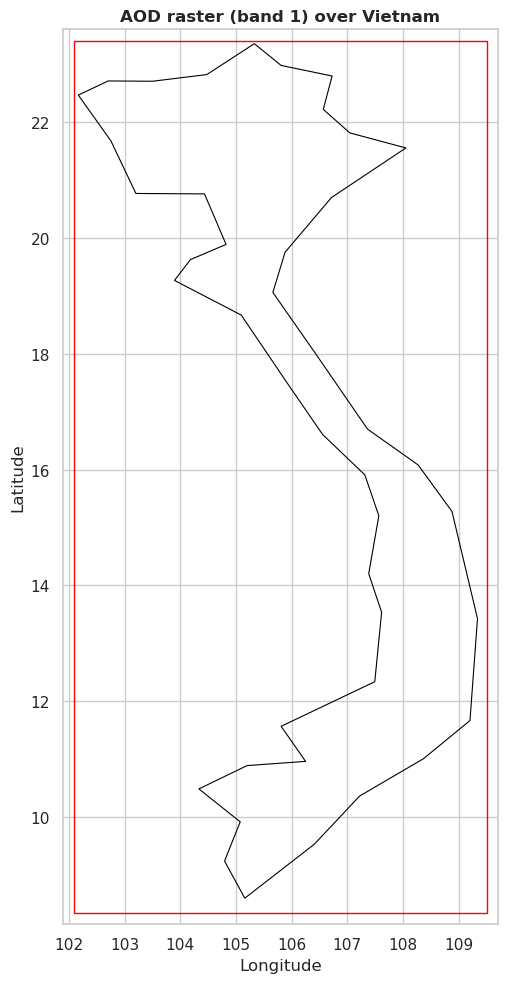

In [60]:
with rasterio.open(sample_file) as src:
    bounds = src.bounds           # left, bottom, right, top
    crs = src.crs                 # e.g. EPSG:4326
    transform = src.transform
    width, height = src.width, src.height
    count = src.count
    dtype = src.dtypes[0]

    # Read the first band for plotting (modify if you want a different band)
    band1 = src.read(2)

# 2) Create a GeoDataFrame for the raster bounds (polygon)
raster_box = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
raster_gdf = gpd.GeoDataFrame({"geometry": [raster_box]}, crs=crs)

# 3) Load Natural Earth countries from URL
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

# 4) Select Vietnam (or show whole region)
vietnam = world[world["ADMIN"] == "Vietnam"]

# 5) Plot: country base, raster as image, raster bounds polygon overlay
fig, ax = plt.subplots(figsize=(8, 10))

# Plot Vietnam (reproject if necessary)
if vietnam.crs != raster_gdf.crs:
    vietnam_plot = vietnam.to_crs(raster_gdf.crs)
else:
    vietnam_plot = vietnam

vietnam_plot.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8)

band1[band1==-9999.0] = np.nan 

# Plot raster using rasterio's show. We supply the extent so it falls in map coords.
# If your raster CRS is geographic (EPSG:4326) this will align with Vietnam as lon/lat.
rioshow(band1,
        transform=transform,
        ax=ax,
        title="AOD raster (band 1) over Vietnam",
        cmap="viridis",)    # you can change colormap

# Draw bounding box on top
raster_gdf.boundary.plot(ax=ax, color="red", linewidth=1)

# Optional: annotate metadata
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(bounds.left - 0.2, bounds.right + 0.2)
ax.set_ylim(bounds.bottom - 0.2, bounds.top + 0.2)

plt.tight_layout()
plt.savefig("raster_over_vietnam.png", dpi=200)
plt.show()

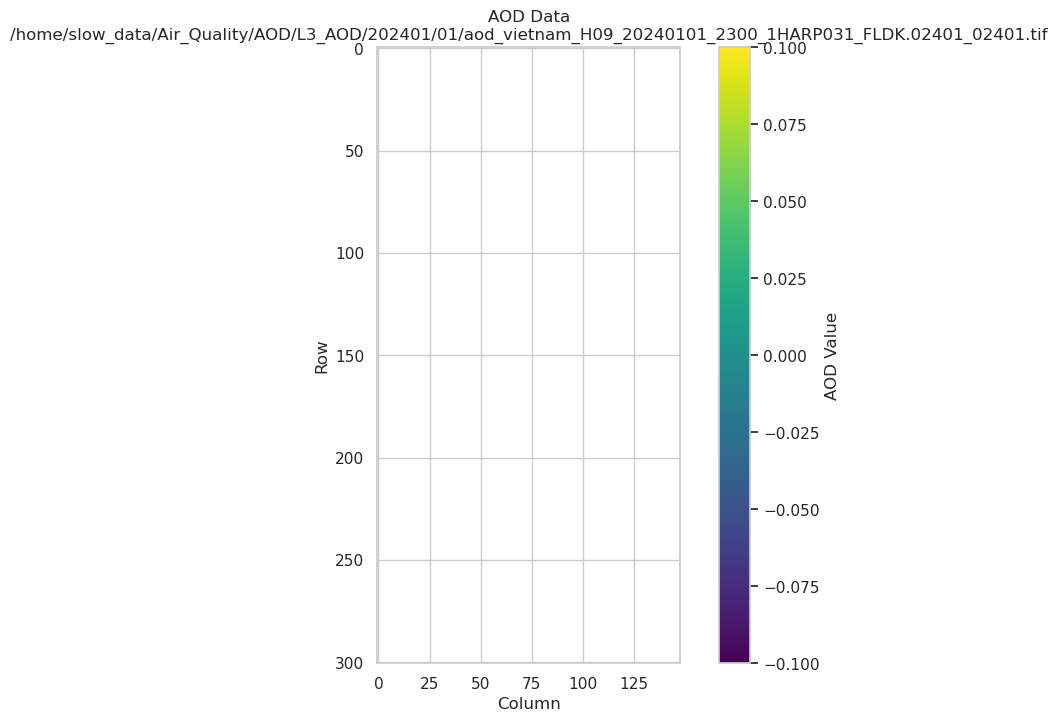

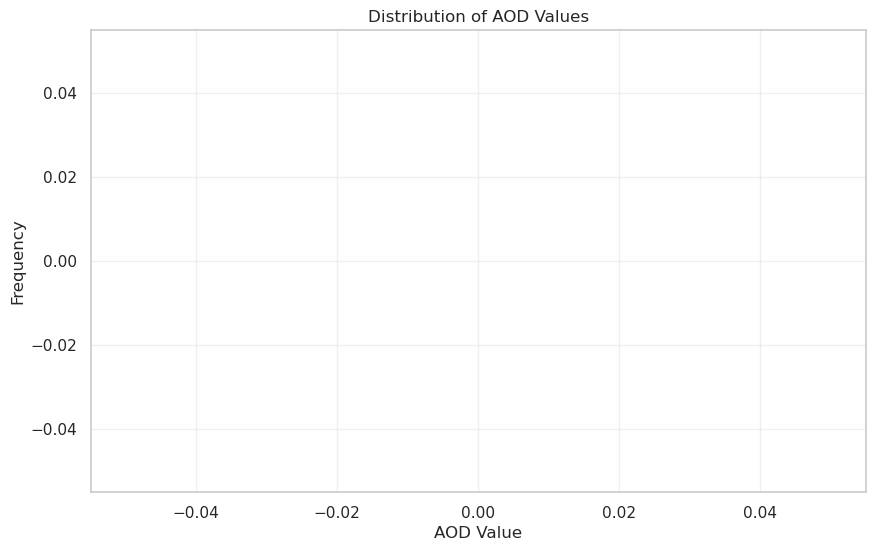

In [62]:


# Load the data once
with rasterio.open(sample_file) as src:
    data = src.read(2)
    # Replace nodata values with NaN
    data[data == -9999.0] = np.nan 

# --- Plot 1: Raw Data Map ---
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap='viridis')
plt.title(f'AOD Data\n{sample_file}')
plt.xlabel('Column')
plt.ylabel('Row')
plt.colorbar(label='AOD Value')
plt.show()

# --- Plot 2: Distribution/Line Plot ---
plt.figure(figsize=(10, 6))
valid_data = data[~np.isnan(data)]
plt.plot(valid_data.flatten(), color='black')
plt.xlabel('AOD Value')
plt.ylabel('Frequency')
plt.title('Distribution of AOD Values')
plt.grid(True, alpha=0.3)
plt.show()
